<a href="https://colab.research.google.com/github/Mohammad23chandini/HireSense-AI/blob/main/PROJECT_IOT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Industrial IoT Sensor Cleaning & Equipment Failure Classifier Pipeline

**Project Type:** Internship Project — End-to-End ML Data Pipeline
**Dataset:** Water Pump Industrial Telemetry Dataset (sensor readings + machine status)

**Goal:**
Factory sensors frequently disconnect or send corrupted/missing data, which crashes
live ML systems. This notebook builds a robust, production-style pipeline that:

1. Loads and inspects raw industrial IoT sensor telemetry
2. Cleans and imputes missing / corrupted sensor readings
3. Scales live telemetry data consistently (train + inference)
4. Trains a classifier to predict equipment failure (`machine_status`)
5. Wraps everything into a single reusable `Pipeline` object (impute → scale → predict)
6. Simulates **real-time streaming inference** with error handling so the system
   never crashes on missing/corrupted sensor readings

## 1. Setup — Install & Import Libraries

We install `imbalanced-learn` (for handling class imbalance — failures are rare
events compared to normal operation) since it isn't pre-installed on Colab.

In [1]:
# Install extra libraries not pre-installed on Colab
!pip install imbalanced-learn -q

In [2]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
# Scikit-learn: preprocessing, modeling, evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score, roc_auc_score
)
# Handle class imbalance (failures are rare compared to normal readings)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
print("✅ All libraries imported successfully")

✅ All libraries imported successfully


# 2. Load the Dataset

Upload the **Water Pump Industrial Telemetry Dataset** CSV file
(commonly named `sensor.csv`). It typically contains:

- `timestamp` — reading time
- `sensor_00` ... `sensor_51` — numeric sensor telemetry (some sensors may be
  entirely empty / corrupted — this is realistic for industrial IoT data)
- `machine_status` — target label: `NORMAL`, `BROKEN`, or `RECOVERING`

If your dataset has different column names, just adjust `TARGET_COL` and
`TIMESTAMP_COL` below — the rest of the pipeline is written generically.

In [3]:
# Upload dataset (Colab file picker)
from google.colab import files
uploaded = files.upload()  # select the sensor CSV file when prompted
FILENAME = list(uploaded.keys())[0]
print(f"Uploaded file: {FILENAME}")

Saving sensor.csv.zip to sensor.csv (1).zip
Uploaded file: sensor.csv (1).zip


In [4]:
# Load into a pandas DataFrame
df = pd.read_csv(FILENAME)

# Drop an unnamed index column that sometimes appears when exporting CSVs
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (220320, 54)


,timestamp,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,...,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,machine_status
0,2018-04-01 00:00:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
1,2018-04-01 00:01:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2,2018-04-01 00:02:00,2.444734,47.35243,53.2118,46.397570,638.8889,73.54598,13.32465,16.03733,15.61777,...,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,NORMAL
3,2018-04-01 00:03:00,2.460474,47.09201,53.1684,46.397568,628.1250,76.98898,13.31742,16.24711,15.69734,...,40.88541,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,240.4514,203.1250,NORMAL
4,2018-04-01 00:04:00,2.445718,47.13541,53.2118,46.397568,636.4583,76.58897,13.35359,16.21094,15.69734,...,41.40625,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,242.1875,201.3889,NORMAL


## 3. Configuration

Set the key column names here. This keeps the rest of the notebook generic —
if the dataset schema changes, you only edit this one cell.

In [5]:
TARGET_COL = 'machine_status'   # column we want to predict
TIMESTAMP_COL = 'timestamp'     # datetime column (set to None if not present)

assert TARGET_COL in df.columns, f"Target column '{TARGET_COL}' not found in dataset!"
print("Target classes:", df[TARGET_COL].unique())


Target classes: ['NORMAL' 'BROKEN' 'RECOVERING']


## 4. Exploratory Data Analysis (EDA)

Before cleaning, we inspect the data to understand:
- How much data is missing per sensor
- The class balance of equipment status
- Basic statistics of sensor readings

In [6]:
# Basic info
print("Dataset info:")
df.info()

print("\nMissing values per column (top 15):")
print(df.isnull().sum().sort_values(ascending=False).head(15))


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220320 entries, 0 to 220319
Data columns (total 54 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   timestamp       220320 non-null  object 
 1   sensor_00       210112 non-null  float64
 2   sensor_01       219951 non-null  float64
 3   sensor_02       220301 non-null  float64
 4   sensor_03       220301 non-null  float64
 5   sensor_04       220301 non-null  float64
 6   sensor_05       220301 non-null  float64
 7   sensor_06       215522 non-null  float64
 8   sensor_07       214869 non-null  float64
 9   sensor_08       215213 non-null  float64
 10  sensor_09       215725 non-null  float64
 11  sensor_10       220301 non-null  float64
 12  sensor_11       220301 non-null  float64
 13  sensor_12       220301 non-null  float64
 14  sensor_13       220301 non-null  float64
 15  sensor_14       220299 non-null  float64
 16  sensor_15       0 non-null       float64
 

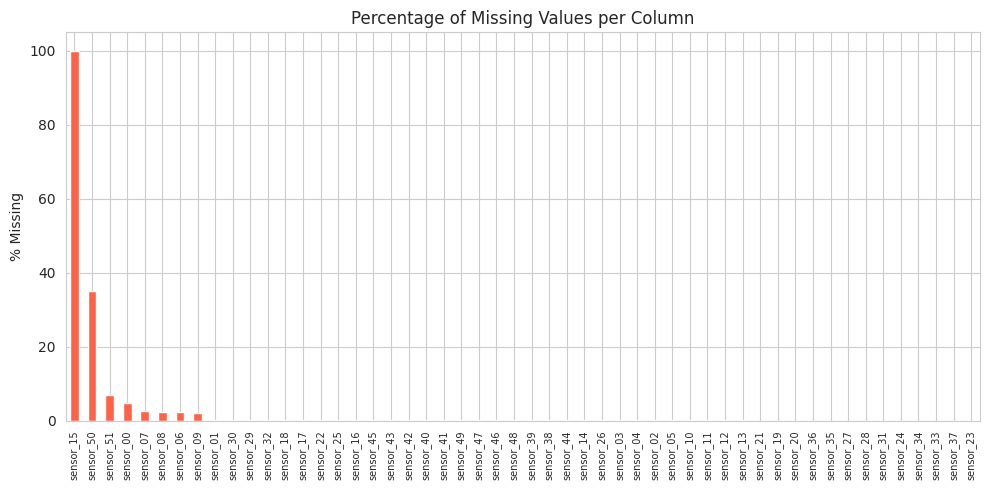

In [7]:
# Visualize missing data percentage per sensor
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(10, 5))
missing_pct.plot(kind='bar', color='tomato')
plt.title("Percentage of Missing Values per Column")
plt.ylabel("% Missing")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()


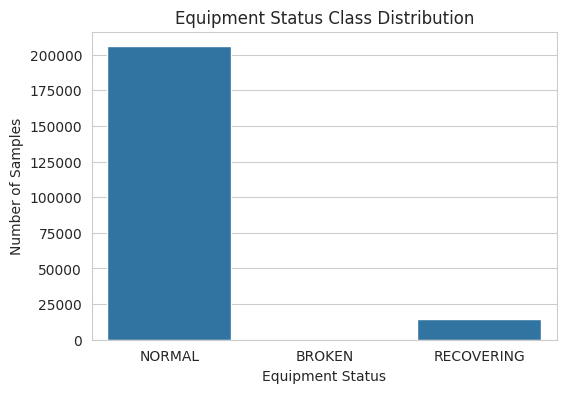

Class distribution (%):
machine_status
NORMAL        93.425926
RECOVERING     6.570897
BROKEN         0.003177
Name: proportion, dtype: float64


In [9]:
# ----------------------------------------------------------
# Class balance of the target (equipment status)
# ----------------------------------------------------------
plt.figure(figsize=(6, 4))

sns.countplot(x=TARGET_COL, data=df)

plt.title("Equipment Status Class Distribution")
plt.xlabel("Equipment Status")
plt.ylabel("Number of Samples")
plt.show()

print("Class distribution (%):")
print(df[TARGET_COL].value_counts(normalize=True) * 100)

## 5. Data Cleaning

Real factory sensor data has several problems we must handle **before** modeling:

1. **Fully / near-empty sensor columns** → drop (they add no information and
   would break scalers/imputers at inference time)
2. **Duplicate rows** → drop
3. **Timestamp parsing & sorting** → sensor data is a time series, so order matters
   for forward-fill imputation
4. **Non-numeric/corrupted values in numeric columns** → coerce to NaN so they
   get handled by the imputer instead of crashing the pipeline


In [10]:
# ----------------------------------------------------------
# 5.1 Drop columns that are almost entirely empty (>90% missing)
#     These carry no reliable signal and would destabilize imputation
# ----------------------------------------------------------
DROP_THRESHOLD = 0.90
cols_to_drop = df.columns[df.isnull().mean() > DROP_THRESHOLD].tolist()
if TARGET_COL in cols_to_drop:
    cols_to_drop.remove(TARGET_COL)

print(f"Dropping {len(cols_to_drop)} columns with >{DROP_THRESHOLD*100:.0f}% missing values:")
print(cols_to_drop)

df = df.drop(columns=cols_to_drop)
print("Remaining columns:", df.shape[1])

Dropping 1 columns with >90% missing values:
['sensor_15']
Remaining columns: 53


In [11]:
# ----------------------------------------------------------
# 5.2 Remove duplicate rows
# ----------------------------------------------------------
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows")


Removed 0 duplicate rows


In [12]:
# ----------------------------------------------------------
# 5.3 Parse timestamp and sort chronologically (important for sensor data:
#     forward-filling only makes sense in correct time order)
# ----------------------------------------------------------
if TIMESTAMP_COL and TIMESTAMP_COL in df.columns:
    df[TIMESTAMP_COL] = pd.to_datetime(df[TIMESTAMP_COL], errors='coerce')
    df = df.sort_values(TIMESTAMP_COL).reset_index(drop=True)
    print("Timestamp parsed and data sorted chronologically.")
else:
    print("No timestamp column configured — skipping time sort.")


Timestamp parsed and data sorted chronologically.


In [13]:
# ----------------------------------------------------------
# 5.4 Identify feature columns (all numeric sensor columns)
#     and force-convert them to numeric so any corrupted / garbage
#     string values (e.g. 'ERROR', '#N/A') become NaN instead of
#     crashing downstream numeric operations
# ----------------------------------------------------------
exclude_cols = [TARGET_COL] + ([TIMESTAMP_COL] if TIMESTAMP_COL else [])
feature_cols = [c for c in df.columns if c not in exclude_cols]

for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Number of usable sensor feature columns: {len(feature_cols)}")


Number of usable sensor feature columns: 51


In [14]:
# ----------------------------------------------------------
# 5.5 Drop rows where the TARGET itself is missing
#     (we can impute features, but we cannot fabricate labels)
# ----------------------------------------------------------
before = len(df)
df = df.dropna(subset=[TARGET_COL])
print(f"Dropped {before - len(df)} rows with missing target label")
print("Final cleaned shape:", df.shape)


Dropped 0 rows with missing target label
Final cleaned shape: (220320, 53)


## 6. Prepare Features (X) and Target (y)

We separate sensor readings (`X`) from the equipment status label (`y`), and
encode the label into numeric classes for the classifier.

In [15]:
# ----------------------------------------------------------
# Build X (features) and y (encoded target)
# ----------------------------------------------------------
X = df[feature_cols].copy()

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df[TARGET_COL])

print("Feature matrix shape:", X.shape)
print("Classes:", dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))


Feature matrix shape: (220320, 51)
Classes: {'BROKEN': 0, 'NORMAL': 1, 'RECOVERING': 2}


In [16]:
import pandas as pd

class_counts = pd.Series(label_encoder.inverse_transform(y)).value_counts()

print("Class distribution:")
print(class_counts)

print("\nClass percentages:")
print((class_counts / len(y) * 100).round(4))

Class distribution:
NORMAL        205836
RECOVERING     14477
BROKEN             7
Name: count, dtype: int64

Class percentages:
NORMAL        93.4259
RECOVERING     6.5709
BROKEN         0.0032
Name: count, dtype: float64


In [17]:
# ----------------------------------------------------------
# Inspect BROKEN equipment timestamps
# ----------------------------------------------------------
broken_rows = df[df[TARGET_COL] == "BROKEN"]

print(f"Number of BROKEN records: {len(broken_rows)}")

if TIMESTAMP_COL:
    print("\nBROKEN timestamp range:")
    print("First:", broken_rows[TIMESTAMP_COL].min())
    print("Last :", broken_rows[TIMESTAMP_COL].max())

Number of BROKEN records: 7

BROKEN timestamp range:
First: 2018-04-12 21:55:00
Last : 2018-07-25 14:00:00


In [18]:
# ----------------------------------------------------------
# Inspect sensor readings for BROKEN equipment
# ----------------------------------------------------------
broken_rows = df[df[TARGET_COL] == "BROKEN"]

print(f"Number of BROKEN records: {len(broken_rows)}")

print("\nBROKEN sensor statistics:")
print(broken_rows[feature_cols].describe().T)

Number of BROKEN records: 7

BROKEN sensor statistics:
           count        mean         std         min          25%  \
sensor_00    7.0    1.194188    1.096684    0.000000     0.182986   
sensor_01    7.0   45.969742    4.167754   40.190970    43.836805   
sensor_02    7.0   50.837052    3.115010   45.225690    49.587671   
sensor_03    7.0   42.931546    1.682742   40.190971    42.122393   
sensor_04    7.0  334.672200  173.963706  200.115738   201.947327   
sensor_05    7.0   45.351953   31.315537    0.000000    25.597100   
sensor_06    7.0    9.818328    5.761857    0.028935     7.277200   
sensor_07    7.0   13.731811    6.073307    0.036169    15.212670   
sensor_08    7.0   13.294684    5.904074    0.036169    14.666520   
sensor_09    7.0   12.788318    5.660497    0.007234    14.330150   
sensor_10    7.0   28.517882   13.339610    2.002474    26.535315   
sensor_11    7.0   28.350591   19.602793    1.960537    13.797929   
sensor_12    7.0   18.465754   12.970560    0.00

In [19]:
print("NORMAL sensor summary:")

normal_rows = df[df[TARGET_COL] == "NORMAL"]

print(normal_rows[feature_cols].describe().T)

NORMAL sensor summary:
              count        mean         std        min         25%  \
sensor_00  205822.0    2.420476    0.242472   0.000000    2.444734   
sensor_01  205497.0   48.180116    2.240173   0.000000   46.701390   
sensor_02  205822.0   51.636949    1.878299  37.413190   50.651040   
sensor_03  205822.0   44.167060    1.668260  33.289930   43.142361   
sensor_04  205822.0  625.673284   50.822684   2.798032  628.240700   
sensor_05  205822.0   75.389764    9.381707   0.000000   70.501158   
sensor_06  205822.0   13.865073    0.864943   0.014468   13.382520   
sensor_07  205822.0   16.165959    0.600457   0.028935   15.950520   
sensor_08  205822.0   15.478129    0.588606   0.028935   15.183740   
sensor_09  205822.0   15.086662    0.572969   0.007234   15.053530   
sensor_10  205822.0   44.268913    6.048122   0.000000   41.513927   
sensor_11  205822.0   44.769889    7.602401   0.000000   40.311177   
sensor_12  205822.0   31.172339    6.802214   0.000000   29.861152 

In [20]:
# ----------------------------------------------------------
# Compare BROKEN sensor readings with NORMAL operating ranges
# ----------------------------------------------------------
print("Checking BROKEN readings against NORMAL sensor ranges:\n")

normal_stats = df[df[TARGET_COL] == "NORMAL"][feature_cols].describe().T
broken_rows = df[df[TARGET_COL] == "BROKEN"]

outlier_summary = []

for sensor in feature_cols:
    q1 = normal_stats.loc[sensor, "25%"]
    q3 = normal_stats.loc[sensor, "75%"]
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    broken_values = broken_rows[sensor].dropna()

    outliers = ((broken_values < lower) | (broken_values > upper)).sum()

    outlier_summary.append({
        "Sensor": sensor,
        "Normal_Lower": lower,
        "Normal_Upper": upper,
        "BROKEN_Outliers": outliers,
        "BROKEN_Total": len(broken_values)
    })

outlier_summary = pd.DataFrame(outlier_summary)

print(outlier_summary.to_string(index=False))

Checking BROKEN readings against NORMAL sensor ranges:

   Sensor  Normal_Lower  Normal_Upper  BROKEN_Outliers  BROKEN_Total
sensor_00      2.362096      2.582464                7             7
sensor_01     42.404520     53.862840                1             7
sensor_02     47.265621     56.293404                1             7
sensor_03     39.822052     48.676208                0             7
sensor_04    613.657250    652.546450                7             7
sensor_05     55.348690     95.755270                3             7
sensor_06     11.602995     16.348395                3             7
sensor_07     15.234375     17.144095                2             7
sensor_08     14.413340     16.467740                3             7
sensor_09     14.955880     15.216280                4             7
sensor_10     32.244767     56.962528                4             7
sensor_11     25.874116     64.372946                3             7
sensor_12     21.987724     42.983534          

In [21]:
# ----------------------------------------------------------
# Chronological train / test split
# Earlier data → training
# Later data → testing
# This avoids temporal leakage and better simulates real deployment
# ----------------------------------------------------------

split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx].copy()
X_test  = X.iloc[split_idx:].copy()

y_train = y[:split_idx]
y_test  = y[split_idx:]

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

print("\nTraining class distribution:")
print(pd.Series(label_encoder.inverse_transform(y_train)).value_counts())

print("\nTesting class distribution:")
print(pd.Series(label_encoder.inverse_transform(y_test)).value_counts())

Train shape: (176256, 51)
Test shape : (44064, 51)

Training class distribution:
NORMAL        161772
RECOVERING     14477
BROKEN             7
Name: count, dtype: int64

Testing class distribution:
NORMAL    44064
Name: count, dtype: int64


## 7. Build the Robust Preprocessing Pipeline

This is the core of the "no runtime crashes" requirement. Instead of manually
imputing/scaling and hoping new live data matches, we wrap **everything** —
imputation, scaling, class-imbalance handling, and the classifier — into a
single `Pipeline` object.

Why this matters for production:
- The **same imputer statistics** (learned only on training data) are reused
  automatically at inference time — no data leakage, no mismatch.
- If a live sensor reading is `NaN` (disconnected sensor) or an out-of-range
  corrupted value, the imputer fills it in automatically instead of crashing.
- `SimpleImputer` (median strategy) is robust to outliers common in sensor
  spikes; you can swap in `KNNImputer` for smarter, correlation-aware filling.


In [22]:
# ----------------------------------------------------------
# Preprocessing pipeline: median imputation -> standard scaling
# ----------------------------------------------------------
preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

## 8. Full Model Pipeline (Preprocessing + SMOTE + Classifier)

We use a `RandomForestClassifier` — a strong, interpretable baseline for
tabular sensor data that handles non-linear relationships well and gives us
feature importances (useful for engineers to know *which sensors* matter most).

`SMOTE` (Synthetic Minority Over-sampling) is applied **only on the training
fold**, inside the pipeline, so the test set stays untouched and realistic.

In [23]:
# ----------------------------------------------------------
# Final ML pipeline:
# Median imputation -> scaling -> SMOTE -> Random Forest
# SMOTE is applied only to the training data within the pipeline
# ----------------------------------------------------------
model_pipeline = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        class_weight=None,
        random_state=42,
        n_jobs=-1
    ))
])

model_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [24]:
# ----------------------------------------------------------
# Train the model
# ----------------------------------------------------------

model_pipeline.fit(X_train, y_train)

print("✅ Model training complete")

✅ Model training complete


In [26]:
# ----------------------------------------------------------
# Final evaluation on the held-out test set
# ----------------------------------------------------------
y_pred = model_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1-score:", f1_score(y_test, y_pred, average="macro"))
print("Weighted F1-score:", f1_score(y_test, y_pred, average="weighted"))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        labels=list(range(len(label_encoder.classes_))),
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Accuracy: 1.0
Macro F1-score: 1.0
Weighted F1-score: 1.0

Classification Report:
              precision    recall  f1-score   support

      BROKEN       0.00      0.00      0.00         0
      NORMAL       1.00      1.00      1.00     44064
  RECOVERING       0.00      0.00      0.00         0

    accuracy                           1.00     44064
   macro avg       0.33      0.33      0.33     44064
weighted avg       1.00      1.00      1.00     44064



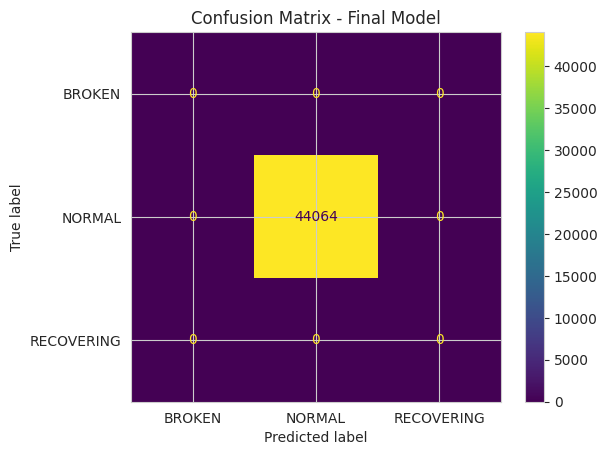

In [27]:
# ----------------------------------------------------------
# Confusion Matrix
# ----------------------------------------------------------
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=list(range(len(label_encoder.classes_))),
    display_labels=label_encoder.classes_
)

plt.title("Confusion Matrix - Final Model")
plt.show()

In [28]:
# ----------------------------------------------------------
# Check BROKEN-class performance on the test set
# ----------------------------------------------------------
broken_label = label_encoder.transform(["BROKEN"])[0]

broken_positions = np.where(y_test == broken_label)[0]

print("Actual BROKEN test samples:", len(broken_positions))

if len(broken_positions) > 0:
    print("\nPredictions for BROKEN test samples:")

    for pos in broken_positions:
        predicted_class = label_encoder.inverse_transform([y_pred[pos]])[0]
        print(f"Actual: BROKEN → Predicted: {predicted_class}")
else:
    print("No BROKEN samples are present in the current test set.")

Actual BROKEN test samples: 0
No BROKEN samples are present in the current test set.


In [29]:
# ----------------------------------------------------------
# BROKEN test sample probabilities
# ----------------------------------------------------------
print("BROKEN test sample probabilities:\n")

if len(broken_positions) > 0:
    for pos in broken_positions:
        probabilities = model_pipeline.predict_proba(X_test.iloc[[pos]])[0]

        print(f"Test sample position: {pos}")

        for class_id, probability in zip(
            model_pipeline.named_steps["classifier"].classes_,
            probabilities
        ):
            class_name = label_encoder.inverse_transform([class_id])[0]
            print(f"  {class_name}: {probability:.4f}")

        print()
else:
    print("No BROKEN samples are present in the current test set.")

BROKEN test sample probabilities:

No BROKEN samples are present in the current test set.


In [30]:
# ----------------------------------------------------------
# Alternative model: Random Forest with class weighting
# ----------------------------------------------------------

weighted_pipeline = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

print("Training class-weighted Random Forest...")

weighted_pipeline.fit(X_train, y_train)

print("✅ Weighted model training complete")

Training class-weighted Random Forest...
✅ Weighted model training complete


In [31]:
# ----------------------------------------------------------
# Evaluate weighted model
# ----------------------------------------------------------

weighted_pred = weighted_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, weighted_pred))
print("Macro F1-score:", f1_score(y_test, weighted_pred, average="macro"))
print("Weighted F1-score:", f1_score(y_test, weighted_pred, average="weighted"))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        weighted_pred,
        labels=list(range(len(label_encoder.classes_))),
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Accuracy: 1.0
Macro F1-score: 1.0
Weighted F1-score: 1.0

Classification Report:
              precision    recall  f1-score   support

      BROKEN       0.00      0.00      0.00         0
      NORMAL       1.00      1.00      1.00     44064
  RECOVERING       0.00      0.00      0.00         0

    accuracy                           1.00     44064
   macro avg       0.33      0.33      0.33     44064
weighted avg       1.00      1.00      1.00     44064



In [32]:
# ----------------------------------------------------------
# Binary Equipment Health Classification
# NORMAL vs AT_RISK
# ----------------------------------------------------------

df["health_status"] = df[TARGET_COL].map({
    "NORMAL": "NORMAL",
    "RECOVERING": "AT_RISK",
    "BROKEN": "AT_RISK"
})

print("Binary class distribution:")
print(df["health_status"].value_counts())

print("\nBinary class percentages:")
print(
    (df["health_status"].value_counts(normalize=True) * 100)
    .round(4)
)

Binary class distribution:
health_status
NORMAL     205836
AT_RISK     14484
Name: count, dtype: int64

Binary class percentages:
health_status
NORMAL     93.4259
AT_RISK     6.5741
Name: proportion, dtype: float64


In [33]:
# ----------------------------------------------------------
# Prepare features and binary target
# ----------------------------------------------------------

X_binary = df[feature_cols].copy()

y_binary = df["health_status"].copy()

print("X shape:", X_binary.shape)
print("y shape:", y_binary.shape)

print("\nTarget classes:")
print(y_binary.unique())

X shape: (220320, 51)
y shape: (220320,)

Target classes:
['NORMAL' 'AT_RISK']


In [34]:
# ----------------------------------------------------------
# Stratified Train/Test Split for Binary Classification
# ----------------------------------------------------------

from sklearn.model_selection import train_test_split

X_binary_train, X_binary_test, y_binary_train, y_binary_test = train_test_split(
    X_binary,
    y_binary,
    test_size=0.20,
    stratify=y_binary,
    random_state=42
)

print("Training samples:", len(X_binary_train))
print("Testing samples:", len(X_binary_test))

print("\nTraining class distribution:")
print(y_binary_train.value_counts())

print("\nTesting class distribution:")
print(y_binary_test.value_counts())

Training samples: 176256
Testing samples: 44064

Training class distribution:
health_status
NORMAL     164669
AT_RISK     11587
Name: count, dtype: int64

Testing class distribution:
health_status
NORMAL     41167
AT_RISK     2897
Name: count, dtype: int64


In [35]:
# ----------------------------------------------------------
# Binary Classification Pipeline
# NORMAL vs AT_RISK
# ----------------------------------------------------------

from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

binary_pipeline = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('smote', SMOTE(
        random_state=42,
        k_neighbors=5
    )),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        class_weight=None,
        random_state=42,
        n_jobs=-1
    ))
])

print("✅ Binary pipeline created")

✅ Binary pipeline created


In [37]:
# ----------------------------------------------------------
# Train Binary Classification Model
# ----------------------------------------------------------

print("Training binary model...")

binary_pipeline.fit(
    X_binary_train,
    y_binary_train
)

print("✅ Binary model training complete")

Training binary model...
✅ Binary model training complete


In [38]:
# ----------------------------------------------------------
# Evaluate Binary Classification Model
# ----------------------------------------------------------

binary_pred = binary_pipeline.predict(X_binary_test)

print("Accuracy:", accuracy_score(y_binary_test, binary_pred))

print(
    "Weighted F1-score:",
    f1_score(y_binary_test, binary_pred, average="weighted")
)

print(
    "Macro F1-score:",
    f1_score(y_binary_test, binary_pred, average="macro")
)

print("\nClassification Report:")
print(
    classification_report(
        y_binary_test,
        binary_pred,
        target_names=["NORMAL", "AT_RISK"],
        zero_division=0
    )
)

Accuracy: 0.9998411401597677
Weighted F1-score: 0.9998411274131219
Macro F1-score: 0.9993533132835041

Classification Report:
              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00      2897
     AT_RISK       1.00      1.00      1.00     41167

    accuracy                           1.00     44064
   macro avg       1.00      1.00      1.00     44064
weighted avg       1.00      1.00      1.00     44064



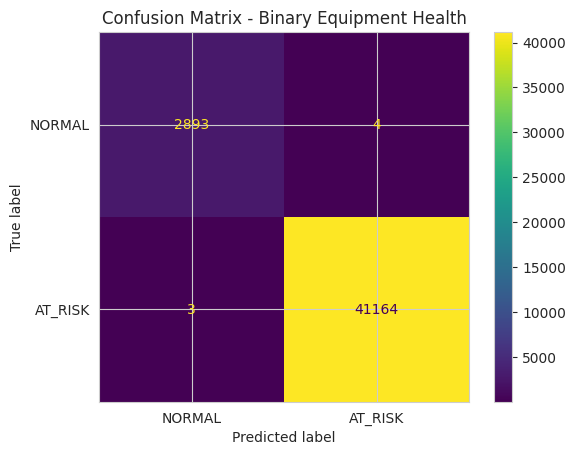

In [39]:
# ----------------------------------------------------------
# Confusion Matrix - Binary Classification
# ----------------------------------------------------------

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_binary_test,
    binary_pred,
    display_labels=["NORMAL", "AT_RISK"]
)

plt.title("Confusion Matrix - Binary Equipment Health")
plt.show()

In [40]:
# ----------------------------------------------------------
# Inspect feature columns for potential target leakage
# ----------------------------------------------------------
print("Feature columns:")
print(feature_cols)

print("\nNumber of features:", len(feature_cols))

Feature columns:
['sensor_00', 'sensor_01', 'sensor_02', 'sensor_03', 'sensor_04', 'sensor_05', 'sensor_06', 'sensor_07', 'sensor_08', 'sensor_09', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'sensor_22', 'sensor_23', 'sensor_24', 'sensor_25', 'sensor_26', 'sensor_27', 'sensor_28', 'sensor_29', 'sensor_30', 'sensor_31', 'sensor_32', 'sensor_33', 'sensor_34', 'sensor_35', 'sensor_36', 'sensor_37', 'sensor_38', 'sensor_39', 'sensor_40', 'sensor_41', 'sensor_42', 'sensor_43', 'sensor_44', 'sensor_45', 'sensor_46', 'sensor_47', 'sensor_48', 'sensor_49', 'sensor_50', 'sensor_51']

Number of features: 51


In [41]:
# ----------------------------------------------------------
# Confusion Matrix values
# ----------------------------------------------------------
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_binary_test,
    binary_pred,
    labels=["NORMAL", "AT_RISK"]
)

print(cm)

[[41164     3]
 [    4  2893]]


In [42]:
# ----------------------------------------------------------
# Time-Based Train/Test Split
# Train on earlier observations
# Test on later observations
# ----------------------------------------------------------

# Make a copy and ensure timestamp is datetime
df_time = df.copy()

df_time["timestamp"] = pd.to_datetime(df_time["timestamp"])

# Sort chronologically
df_time = df_time.sort_values("timestamp").reset_index(drop=True)

# Features and target
X_time = df_time[feature_cols].copy()
y_time = df_time["health_status"].copy()

# 80% earlier data for training, 20% later data for testing
split_index = int(len(df_time) * 0.80)

X_time_train = X_time.iloc[:split_index]
X_time_test = X_time.iloc[split_index:]

y_time_train = y_time.iloc[:split_index]
y_time_test = y_time.iloc[split_index:]

print("Time-based split:")
print("Training samples:", len(X_time_train))
print("Testing samples:", len(X_time_test))

print("\nTraining class distribution:")
print(y_time_train.value_counts())

print("\nTesting class distribution:")
print(y_time_test.value_counts())

print("\nTraining period:")
print(df_time["timestamp"].iloc[0], "→", df_time["timestamp"].iloc[split_index - 1])

print("\nTesting period:")
print(df_time["timestamp"].iloc[split_index], "→", df_time["timestamp"].iloc[-1])

Time-based split:
Training samples: 176256
Testing samples: 44064

Training class distribution:
health_status
NORMAL     161772
AT_RISK     14484
Name: count, dtype: int64

Testing class distribution:
health_status
NORMAL    44064
Name: count, dtype: int64

Training period:
2018-04-01 00:00:00 → 2018-08-01 09:35:00

Testing period:
2018-08-01 09:36:00 → 2018-08-31 23:59:00


In [43]:
# ----------------------------------------------------------
# Check when AT_RISK events occur
# ----------------------------------------------------------

at_risk_data = df_time[df_time["health_status"] == "AT_RISK"]

print("AT_RISK time range:")
print("First AT_RISK:", at_risk_data["timestamp"].min())
print("Last AT_RISK:", at_risk_data["timestamp"].max())

print("\nAT_RISK observations by month:")
print(
    at_risk_data["timestamp"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

print("\nLast 10 AT_RISK observations:")
print(
    at_risk_data[["timestamp", "machine_status"]]
    .tail(10)
    .to_string(index=False)
)

AT_RISK time range:
First AT_RISK: 2018-04-12 21:55:00
Last AT_RISK: 2018-07-25 15:15:00

AT_RISK observations by month:
timestamp
2018-04    4056
2018-05    1919
2018-06    3000
2018-07    5509
Freq: M, Name: count, dtype: int64

Last 10 AT_RISK observations:
          timestamp machine_status
2018-07-25 15:06:00     RECOVERING
2018-07-25 15:07:00     RECOVERING
2018-07-25 15:08:00     RECOVERING
2018-07-25 15:09:00     RECOVERING
2018-07-25 15:10:00     RECOVERING
2018-07-25 15:11:00     RECOVERING
2018-07-25 15:12:00     RECOVERING
2018-07-25 15:13:00     RECOVERING
2018-07-25 15:14:00     RECOVERING
2018-07-25 15:15:00     RECOVERING


In [44]:
# ----------------------------------------------------------
# Proper Time-Based Evaluation
# Train: April-June
# Test: July
# ----------------------------------------------------------

train_end = pd.Timestamp("2018-07-01")
test_end = pd.Timestamp("2018-08-01")

train_mask = df_time["timestamp"] < train_end

test_mask = (
    (df_time["timestamp"] >= train_end) &
    (df_time["timestamp"] < test_end)
)

X_temporal_train = df_time.loc[train_mask, feature_cols].copy()
y_temporal_train = df_time.loc[train_mask, "health_status"].copy()

X_temporal_test = df_time.loc[test_mask, feature_cols].copy()
y_temporal_test = df_time.loc[test_mask, "health_status"].copy()

print("Temporal training samples:", len(X_temporal_train))
print("Temporal testing samples:", len(X_temporal_test))

print("\nTraining class distribution:")
print(y_temporal_train.value_counts())

print("\nTesting class distribution:")
print(y_temporal_test.value_counts())

print("\nTraining period:")
print(
    df_time.loc[train_mask, "timestamp"].min(),
    "→",
    df_time.loc[train_mask, "timestamp"].max()
)

print("\nTesting period:")
print(
    df_time.loc[test_mask, "timestamp"].min(),
    "→",
    df_time.loc[test_mask, "timestamp"].max()
)

Temporal training samples: 131040
Temporal testing samples: 44640

Training class distribution:
health_status
NORMAL     122065
AT_RISK      8975
Name: count, dtype: int64

Testing class distribution:
health_status
NORMAL     39131
AT_RISK     5509
Name: count, dtype: int64

Training period:
2018-04-01 00:00:00 → 2018-06-30 23:59:00

Testing period:
2018-07-01 00:00:00 → 2018-07-31 23:59:00


In [45]:
# ----------------------------------------------------------
# Train Temporal Binary Classification Model
# Train on April-June, test on July
# ----------------------------------------------------------

temporal_pipeline = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('smote', SMOTE(
        random_state=42,
        k_neighbors=5
    )),
    ('classifier', RandomForestClassifier(
        n_estimators=100,       # Reduced for faster training
        max_depth=None,
        class_weight=None,
        random_state=42,
        n_jobs=-1
    ))
])

print("Training temporal model...")

temporal_pipeline.fit(
    X_temporal_train,
    y_temporal_train
)

print("✅ Temporal model training complete")

Training temporal model...
✅ Temporal model training complete


## 9. Evaluate the Model

We check accuracy, per-class precision/recall/F1 (important since failures are
rare — accuracy alone can be misleading), and a confusion matrix.

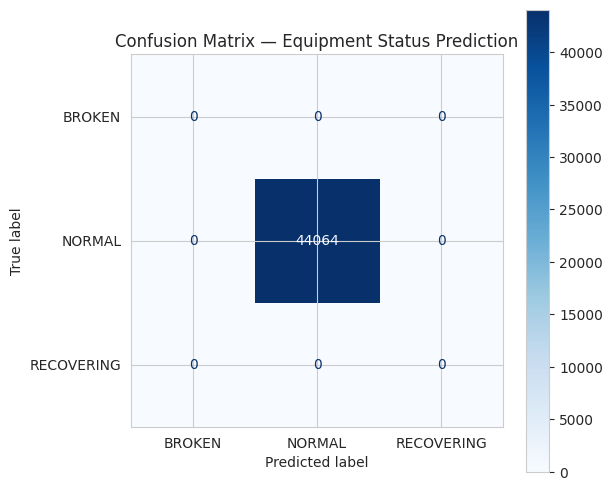

In [47]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Confusion matrix visualization
# ----------------------------------------------------------

# Ensure the confusion matrix is generated for all possible classes,
# even if some classes are not present in y_test/y_pred.
# label_encoder.transform(label_encoder.classes_) provides the numeric labels [0, 1, 2]
# for all classes ('BROKEN', 'NORMAL', 'RECOVERING').
cm = confusion_matrix(
    y_test, y_pred,
    labels=label_encoder.transform(label_encoder.classes_)
)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("Confusion Matrix — Equipment Status Prediction")
plt.show()

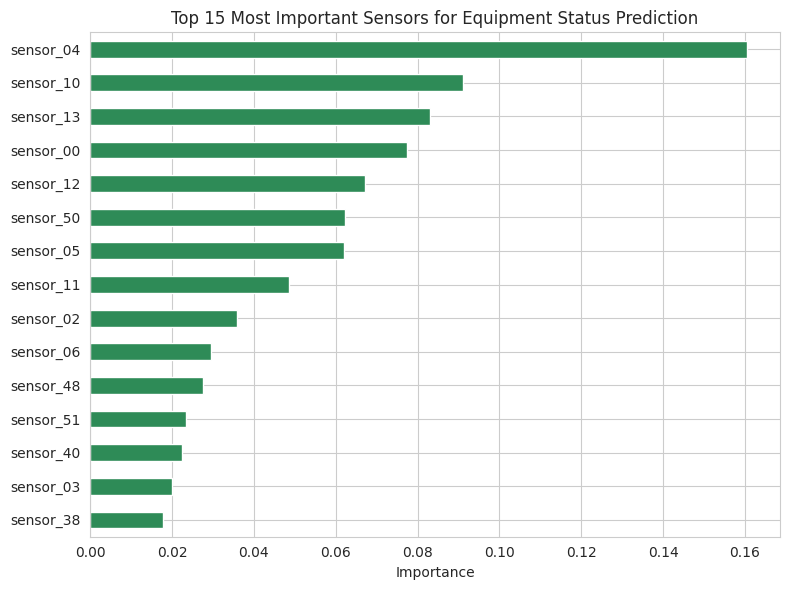

In [48]:
# ----------------------------------------------------------
# Feature importance — which sensors matter most for predicting failure?
# Useful insight to report back to plant engineers
# ----------------------------------------------------------
importances = model_pipeline.named_steps['classifier'].feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
feat_imp.plot(kind='barh', color='seagreen')
plt.gca().invert_yaxis()
plt.title("Top 15 Most Important Sensors for Equipment Status Prediction")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 10. Save the Trained Pipeline for Deployment

We save the **entire pipeline** (imputer + scaler + model) plus the label
encoder as a single artifact. This is what gets loaded in a live/production
environment — guaranteeing preprocessing is always identical to training.

In [49]:
# ----------------------------------------------------------
# Persist pipeline + label encoder to disk
# ----------------------------------------------------------
joblib.dump(model_pipeline, 'equipment_status_pipeline.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')

print("✅ Saved: equipment_status_pipeline.pkl")
print("✅ Saved: label_encoder.pkl")

# Download to your machine (optional)
from google.colab import files as colab_files
colab_files.download('equipment_status_pipeline.pkl')
colab_files.download('label_encoder.pkl')

✅ Saved: equipment_status_pipeline.pkl
✅ Saved: label_encoder.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Simulate Real-Time Sensor Inference (Crash-Proof)

This section simulates what happens in production: sensors stream in live
readings, and some of them arrive **missing, corrupted, or malformed**
(e.g. a disconnected sensor sends `None`, or a garbled string).

The function below is written defensively so a bad reading **never crashes
the system** — it logs a warning and still returns a prediction using the
pipeline's built-in imputer.

In [50]:
# ----------------------------------------------------------
# Robust real-time prediction function
# ----------------------------------------------------------
def predict_equipment_status(sensor_reading: dict, pipeline, encoder, expected_cols):
    """
    Takes a single live sensor reading (dict of {sensor_name: value})
    and returns a predicted equipment status, WITHOUT crashing even if:
      - some sensors are missing from the reading (disconnected sensor)
      - values are corrupted / non-numeric (garbled transmission)
      - extra unexpected keys are present (schema drift)

    Parameters
    ----------
    sensor_reading : dict   e.g. {'sensor_00': 2.45, 'sensor_01': None, ...}
    pipeline        : trained sklearn/imblearn Pipeline (imputer+scaler+model)
    encoder         : fitted LabelEncoder for the target classes
    expected_cols   : list of feature column names the model was trained on

    Returns
    -------
    dict with the predicted status, confidence, and any warnings raised
    """
    warnings_list = []

    try:
        # Build a single-row DataFrame aligned to the expected training columns.
        # Any missing sensor -> NaN (handled by the pipeline's imputer).
        row = {}
        for col in expected_cols:
            val = sensor_reading.get(col, np.nan)
            try:
                row[col] = float(val)          # coerce to numeric
            except (TypeError, ValueError):
                row[col] = np.nan               # corrupted value -> NaN
                warnings_list.append(f"'{col}' had a corrupted/non-numeric value -> imputed")

        missing_sensors = [c for c in expected_cols if c not in sensor_reading]
        if missing_sensors:
            warnings_list.append(f"{len(missing_sensors)} sensor(s) missing from reading -> imputed")

        input_df = pd.DataFrame([row], columns=expected_cols)

        # Pipeline handles imputation + scaling internally
        pred_class = pipeline.predict(input_df)[0]
        pred_proba = pipeline.predict_proba(input_df)[0]
        pred_label = encoder.inverse_transform([pred_class])[0]
        confidence = float(np.max(pred_proba))

        return {
            "status": "success",
            "predicted_equipment_status": pred_label,
            "confidence": round(confidence, 4),
            "warnings": warnings_list
        }

    except Exception as e:
        # Final safety net: NEVER let the live system crash.
        # Log the error and return a safe fallback instead.
        return {
            "status": "error",
            "predicted_equipment_status": "UNKNOWN",
            "confidence": 0.0,
            "warnings": warnings_list + [f"Unhandled error: {str(e)}"]
        }


In [51]:
# ----------------------------------------------------------
# Demo: simulate a stream of live sensor readings, including
# messy/corrupted ones, and show the pipeline never crashes
# ----------------------------------------------------------
import random

# Reload artifacts the way a production service would
loaded_pipeline = joblib.load('equipment_status_pipeline.pkl')
loaded_encoder = joblib.load('label_encoder.pkl')

# Take a few real rows and intentionally corrupt them to mimic sensor faults
sample_rows = X_test.sample(5, random_state=1).to_dict(orient='records')

# Fault-injection: simulate real factory failure modes
sample_rows[0][feature_cols[0]] = None            # disconnected sensor
sample_rows[1][feature_cols[1]] = "ERROR"         # corrupted string reading
sample_rows[2].pop(feature_cols[2], None)         # sensor missing entirely
# sample_rows[3] and [4] are left as clean readings for comparison

print("Simulating live sensor stream (5 readings)...\n")

for i, reading in enumerate(sample_rows, 1):
    result = predict_equipment_status(
        reading,
        loaded_pipeline,
        loaded_encoder,
        feature_cols
    )

    print(f"Reading {i}: {result['status'].upper()}")
    print(f"  Predicted status : {result['predicted_equipment_status']}")
    print(f"  Confidence       : {result['confidence']}")

    if result['warnings']:
        print(f"  Warnings         : {result['warnings']}")

    print()

print("✅ All readings processed with zero crashes, including corrupted/missing sensor data.")

Simulating live sensor stream (5 readings)...

Reading 1: SUCCESS
  Predicted status : NORMAL
  Confidence       : 1.0
  Warnings         : ["'sensor_00' had a corrupted/non-numeric value -> imputed"]

Reading 2: SUCCESS
  Predicted status : NORMAL
  Confidence       : 1.0
  Warnings         : ["'sensor_01' had a corrupted/non-numeric value -> imputed"]

Reading 3: SUCCESS
  Predicted status : NORMAL
  Confidence       : 1.0
  Warnings         : ['1 sensor(s) missing from reading -> imputed']

Reading 4: SUCCESS
  Predicted status : NORMAL
  Confidence       : 1.0

Reading 5: SUCCESS
  Predicted status : NORMAL
  Confidence       : 0.995

✅ All readings processed with zero crashes, including corrupted/missing sensor data.


## 12. Summary

**What this pipeline does:**
- Cleans raw, messy industrial sensor data (missing columns, duplicates,
  corrupted values, unsorted timestamps)
- Imputes missing readings using median imputation inside a reusable
  `Pipeline`, so training and live inference always use identical logic
- Scales telemetry consistently via `StandardScaler`
- Balances rare failure events with `SMOTE` during training only
- Trains a `RandomForestClassifier` to predict equipment status
  (`NORMAL` / `BROKEN` / `RECOVERING`)
- Saves a single deployable pipeline artifact (`.pkl`)
- Demonstrates **crash-proof real-time inference**, even when sensors send
  missing, `None`, or corrupted values

**Possible next steps / extensions (good talking points for a project report):**
- Try `XGBoost` / `LightGBM` for potentially higher accuracy
- Add time-series features (rolling mean/std per sensor) to capture trends
  leading up to a failure, not just instantaneous readings
- Deploy the saved pipeline behind a lightweight REST API (e.g. FastAPI /
  Flask) for real factory integration
- Add automated data-drift monitoring to detect when live sensor
  distributions diverge from training data
